In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Task 1:Exploratory Data Analysis (EDA)

In [2]:
df=pd.read_csv("./Fifa.csv")

In [3]:
df.shape

(19667, 9)

- The dataset has 19,667 players and 9 columns.

In [4]:
df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


- as we see we have 5 numircal features and 4 Categorical features

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB


In [6]:
df.duplicated().sum()

np.int64(0)

- as shown there ara no duplicated

In [7]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

- as shown there ara no null values

In [8]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


- Age: ranges from 15 to 44, with an average of 22.99, indicating that most players are relatively young.
- Overall Rating: ranges from 36 to 91, with a mean of 63.23, showing that the majority of players have moderate skill levels.
- Future Potential: ranges from 46 to 95, with an average of 70.66, suggesting many players can develop.
- Value Per M$: ranges from 0 to 190.5, showing huge differeence between players,because some of them ara.
-Total Stats Score: ranges from 416 to 2324, reflecting major differences in player abilities.


## Distribution of Value Per M$

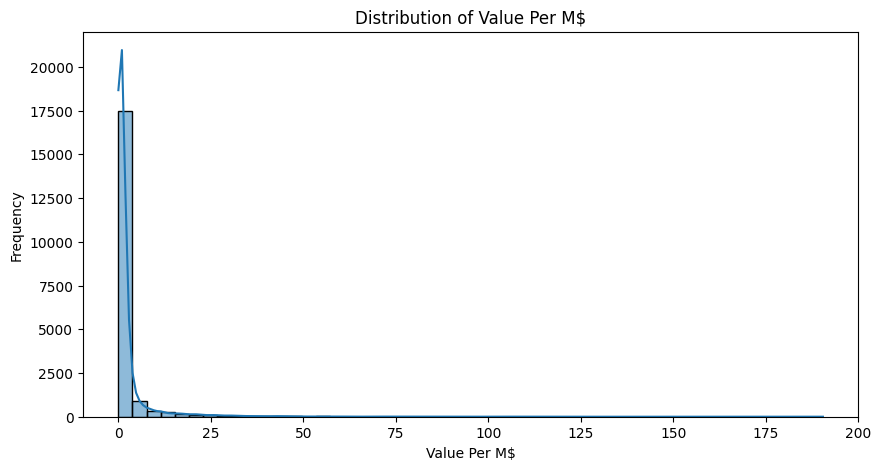

Skewness = 7.983215201865151


In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df["Value Per M$"], bins=50, kde=True)
plt.title("Distribution of Value Per M$")
plt.xlabel("Value Per M$")
plt.ylabel("Frequency")
plt.show()
skew_value = df["Value Per M$"].skew()
print("Skewness =", skew_value)

- as we see the distribution of Value Per M$ is highly positively skewed (right-skewed) and is not approximately normal.



## Which numerical features seem most related to Value Per M$?

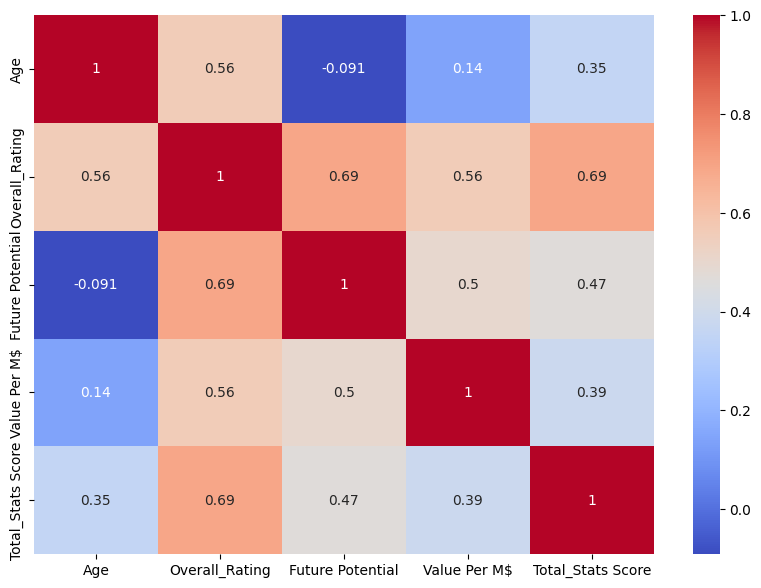

In [10]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

- as shown the most related to Value Per M$ is Overall_Rating 



## What is the average Overall_Rating per Position? 

In [11]:
df.groupby('Position')['Overall_Rating'].mean()

Position
CAM    63.679709
CB     63.544448
CDM    64.234168
CF     66.042857
CM     62.511767
GK     60.987288
LB     63.276794
LM     64.172009
LW     64.345979
LWB    64.043333
RB     62.863636
RF     75.000000
RM     63.907731
RW     63.718529
RWB    64.063973
ST     63.087505
SW     75.000000
Name: Overall_Rating, dtype: float64

<Axes: xlabel='Position', ylabel='Overall_Rating'>

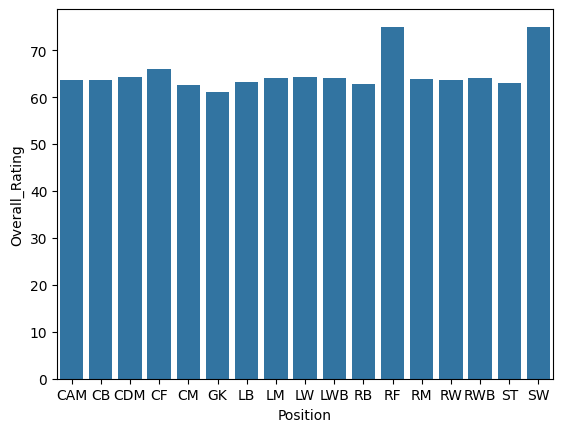

In [12]:
sns.barplot(df.groupby('Position')['Overall_Rating'].mean())

---

# Task 2: Data Preprocessing

- Split the dataset into Train and Test sets

In [13]:
from sklearn.model_selection import train_test_split
X = df.drop('Value Per M$', axis=1)    
y = df['Value Per M$']                
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2 ,random_state=42 )
print(f'Training set size : {X_train.shape}')
print(f'Test set size: {X_test.shape}')

Training set size : (15733, 8)
Test set size: (3934, 8)




## Outlier Detection and Removal

In [14]:
train_df = X_train.copy()
train_df['Value Per M$'] = y_train.values
outlier_cols = ['Value Per M$', 'Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
print(train_df.shape)

(15733, 9)


- Outlier Preparation:
We copy X_train and add the target column Value Per M$ to create train_df.
We also define the columns that will be checked for outliers.
Finally, we print the dataset shape before removing outliers.

In [15]:
for col in outlier_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train_df = train_df[(train_df[col] >= lower) & (train_df[col] <= upper)]

In [16]:
train_df = train_df.reset_index(drop=True)
print(train_df.shape)
print(X_train.shape[0] - train_df.shape[0])

(12375, 9)
3358


In [17]:
X_train_clean = train_df.drop(columns=['Value Per M$'])
y_train_clean = train_df['Value Per M$']

- we separated X_train_clean and y_train_clean

In [18]:
X_train

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Mizuki Arai,Japan,LW,25,67,70,Gil Vicente,1689
10392,Juan Felipe Moreno,Colombia,ST,19,55,68,Midtjylland,1351
8124,Fábio Alexandre Silva Coentrão,Portugal,RW,32,75,75,Rio Ave,2049
13075,Luís Fellipe Rodrigues Mota,Portugal,ST,17,61,71,Belenenses,1448
19445,Juan Acosta,Uruguay,RB,28,69,69,Wanderers,1748
...,...,...,...,...,...,...,...,...
11284,Maikel Reyes,Ecuador,CM,19,59,70,Delfin,1680
11964,Visar Musliu,North Macedonia,CB,27,67,68,Ingolstadt,1557
5390,Yuki Ohashi,Japan,ST,24,63,67,Shonan Bellmare,1568
860,Wilfred Ndidi,Nigeria,CM,25,81,82,Leicester City,2042


In [19]:
y_train

10156     1.300
10392     0.300
8124      3.900
13075     0.675
19445     1.300
          ...  
11284     0.475
11964     1.000
5390      0.700
860      27.500
15795     1.200
Name: Value Per M$, Length: 15733, dtype: float64

In [20]:
X_train_clean

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
0,Mizuki Arai,Japan,LW,25,67,70,Gil Vicente,1689
1,Juan Felipe Moreno,Colombia,ST,19,55,68,Midtjylland,1351
2,Luís Fellipe Rodrigues Mota,Portugal,ST,17,61,71,Belenenses,1448
3,Juan Acosta,Uruguay,RB,28,69,69,Wanderers,1748
4,Felix Passlack,Germany,CM,24,70,73,Borussia Dortmund,1960
...,...,...,...,...,...,...,...,...
12370,David Mindombe,Belgium,CB,19,58,71,Sint-Truiden,1383
12371,Maikel Reyes,Ecuador,CM,19,59,70,Delfin,1680
12372,Visar Musliu,North Macedonia,CB,27,67,68,Ingolstadt,1557
12373,Yuki Ohashi,Japan,ST,24,63,67,Shonan Bellmare,1568


In [21]:
y_train_clean

0        1.300
1        0.300
2        0.675
3        1.300
4        2.200
         ...  
12370    0.450
12371    0.475
12372    1.000
12373    0.700
12374    1.200
Name: Value Per M$, Length: 12375, dtype: float64

## Encoding Categorical Features (One-Hot Encoding)

#### Why We Use One-Hot Encoding

We use One-Hot Encoding instead of Label Encoding because Label Encoding assigns numbers to categories (like 0, 1, 2) which can wrongly make the model think there is an order or ranking between them.
One-Hot Encoding solves this by creating separate columns for each category with values 0 or 1 so all categories are treated equally without any order.

In [22]:
cat_cols = X_train_clean.select_dtypes(include='object').columns.tolist()
cat_cols

/tmp/ipykernel_612946/2995957462.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_clean.select_dtypes(include='object').columns.tolist()


['Name', 'Country', 'Position', 'Team']

In [23]:
X_train_encoded = pd.get_dummies(X_train_clean, columns=cat_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test,columns=cat_cols, drop_first=True)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)
print(f'\nShape after encoding  Train: {X_train_encoded.shape}, Test: {X_test_encoded.shape}')
X_train_encoded.head()


Shape after encoding  Train: (12375, 13485), Test: (3934, 13485)


,Age,Overall_Rating,Future Potential,Total_Stats Score,Name_ Fábio Paim,Name_ Jean,Name_ Marcão,Name_ Paulinho,Name_ Paulo Miranda,Name_ Pedrinho,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
0,25,67,70,1689,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,19,55,68,1351,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,17,61,71,1448,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,28,69,69,1748,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,24,70,73,1960,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



## Scale numerical features:

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = X_train_encoded.select_dtypes(include='number').columns
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

- Why StandardScaler over MinMaxScaler  
We use Standard Scaling to make numerical features have a mean of 0 and a standard deviation of 1.
This is important because it ensures that all features are on the same scale, so no feature dominates others due to large values.
We prefer Standard Scaling because it works well with many machine learning models like Logistic Regression, SVM, KNN, and Neural Networks.

In [25]:
print(X_train_scaled[:6])

[[ 0.60835546  0.89482666  0.06660141 ... -0.03598059 -0.01557187
  -0.03598059]
 [-0.81828824 -1.13210764 -0.31400003 ... -0.03598059 -0.01557187
  -0.03598059]
 [-1.29383614 -0.11864049  0.25690213 ... -0.03598059 -0.01557187
  -0.03598059]
 [ 1.32167731  1.23264905 -0.12369931 ... -0.03598059 -0.01557187
  -0.03598059]
 [ 0.37058151  1.40156024  0.63750357 ... -0.03598059 -0.01557187
  -0.03598059]
 [ 0.13280756 -0.11864049 -0.88490219 ... -0.03598059 -0.01557187
  -0.03598059]]


# Task 3 : Classification Target (Logistic Regression + Naïve Bayes)

In [26]:
df['Performance_Tier'] = pd.qcut(df['Overall_Rating'], q=4, labels=['Tier 4', 'Tier 3', 'Tier 2', 'Tier 1'])

In [27]:
thresholds = df['Overall_Rating'].describe(percentiles=[.25, .5, .75])
print("Defined Thresholds for Performance Tiers:")
print(thresholds)

Defined Thresholds for Performance Tiers:
count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64


###1. Calculate the number of players in each category

In [28]:
counts = df['Performance_Tier'].value_counts().sort_index()
print("\nPlayer Counts per Category:")
print(counts)


Player Counts per Category:
Performance_Tier
Tier 4    5568
Tier 3    5102
Tier 2    4297
Tier 1    4700
Name: count, dtype: int64


In [29]:
#### 2. Plotting the Bar Chart to visualize class distribution

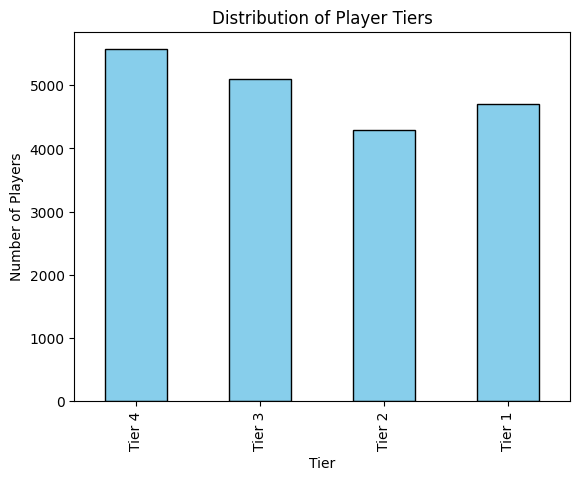

In [30]:
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Player Tiers')
plt.xlabel('Tier')
plt.ylabel('Number of Players')
plt.show()

## Conclusion:
 The dataset is balanced. Since each tier contains approximately 25% of the total players, the classes are evenly distributed. This ensures that the classification models (Logistic Regression and Naïve Bayes) will not be biased toward any specific category.

## Justification:
 We used quantile-based discretization (quartiles) to define the thresholds. This approach was chosen to ensure that the performance tiers are defined relative to the current player population, maintaining an equal number of samples in each class for optimal model training.

# Task 4: Polynomial Regression

In [53]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,root_mean_squared_error

In [32]:
model = LinearRegression()

In [33]:
def polynomial_feature(dataframe,columns=num_cols,degrees:list=[2,3,4])->pd.DataFrame:
    data = dataframe.copy()

    for deg in degrees:
        for col in columns:
            data[col+'^'+str(deg)] = data[col]**deg

    return data

In [34]:
degrees = 4

In [35]:
X_train_scaled_num = pd.DataFrame(X_train_scaled,columns=X_train_encoded.columns)[num_cols]
X_test_scaled_num = pd.DataFrame(X_test_scaled,columns=X_test_encoded.columns)[num_cols]


In [36]:
scores = {}
for i in range(1,degrees):
    model.fit(polynomial_feature(X_train_scaled_num,num_cols,degrees=[i for i in range(2,i+1)]),y_train_clean)
    predictions = model.predict(polynomial_feature(X_test_scaled_num,num_cols,degrees=[i for i in range(2,i+1)]))

    train_R2 = model.score(polynomial_feature(X_train_scaled_num,num_cols,degrees=[i for i in range(2,i+1)]),y_train_clean)
    test_R2 = r2_score(y_test,predictions)

    scores['Polynomial of Degree '+str(i)] = {'train R2':train_R2,'Test R2':test_R2}


In [37]:
scores

{'Polynomial of Degree 1': {'train R2': 0.7175852178830333,
  'Test R2': 0.07955329286880841},
 'Polynomial of Degree 2': {'train R2': 0.830086193178365,
  'Test R2': 0.20539666872221318},
 'Polynomial of Degree 3': {'train R2': 0.8362094898911515,
  'Test R2': 0.1596158834618171}}

second degree polynomial is the best at genaralizing even though the third degree polynomial is better in the train set

In [48]:
X_train_squared = polynomial_feature(X_train_scaled_num,num_cols,degrees=[2])
X_test_squared = polynomial_feature(X_test_scaled_num,num_cols,degrees=[2])


In [129]:
losses = {}
alpha = np.logspace(-4,1,200)
models = (Ridge,Lasso)
for model in models:
    loss = []
    for a in alpha:
        m = model(alpha=a)
        m.fit(X_train_squared,y_train_clean)
        predictions =  m.predict(X_test_squared)
        loss.append(root_mean_squared_error(y_test,predictions))
    losses[model.__name__] = loss

In [130]:
losses = pd.DataFrame(losses)

In [131]:
losses['alpha'] = alpha

In [132]:
losses

,Ridge,Lasso,alpha
0,7.020735,7.021167,0.000100
1,7.020735,7.021193,0.000106
2,7.020735,7.021220,0.000112
3,7.020735,7.021249,0.000119
4,7.020735,7.021279,0.000126
...,...,...,...
195,7.021525,8.064843,7.934097
196,7.021572,8.064843,8.406653
197,7.021621,8.064843,8.907355
198,7.021674,8.064843,9.437878


<Axes: ylabel='Lasso'>

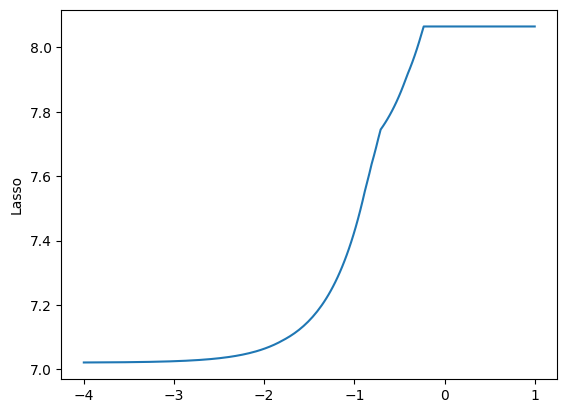

In [ ]:
sns.lineplot(x=np.log10(alpha),y=losses['Lasso'])

<Axes: ylabel='Ridge'>

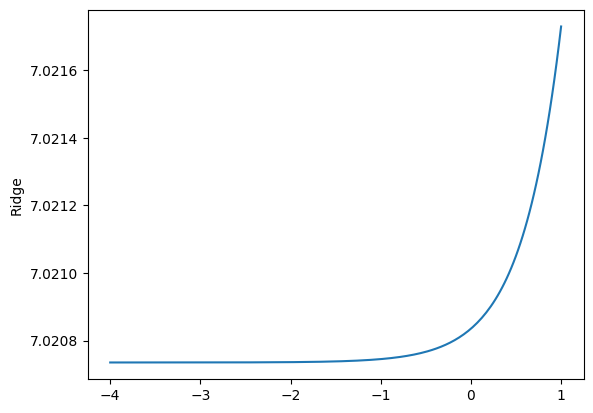

In [134]:
sns.lineplot(x=np.log10(alpha),y=losses['Ridge'])